In [1]:
############################## Cloud Cover Forcing File #####################################
# The purpose of this script is to make a forcing file for cloud cover
#  from 2017 - 2024 to use for bulk fluxes for ROMS. 
#
# Notes:
# - We will like hold off on interpolating and let ROMS interpolate the data instead...
#   but if this gets wonky then this script will interpolate it before saving it.
# - ERA5 data is hourly starting at hour 1 day 1 each year; time in ERA5? output is 
#   UTC so subtract 9 for standard time and 8 for daylight savings...but I think do something uniform 
#   for now so subtract 8 for now...
#
############################################################################################

In [2]:
# Load in packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib import colors
import cartopy.crs as ccrs
from cartopy import config
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean 
import xarray as xr
import datetime
from datetime import datetime, timedelta
import xesmf as xe
#import ESMF
from netCDF4 import Dataset
from datetime import datetime, timedelta
from cftime import num2date, date2num
import pandas as pd  
import math
#from PythonMETAR import *

In [3]:
# Load in the grid
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_2020_test_nosed/Include/KakAKgrd_shelf_big010_smooth006_thin_sponge.nc')


In [4]:
# Set a bunch of dimensions 

# Pull out the angle to rotate the currents to match the grid's u,v
phi = grid.angle[0,0].values # radians 

# Read in the dimensions
# rho
eta_rho_len = len(grid.eta_rho) # 206
xi_rho_len = len(grid.xi_rho) # 608
# u
eta_u_len = len(grid.eta_u) # 206
xi_u_len = len(grid.xi_u) # 607
# v
eta_v_len = len(grid.eta_v) #
xi_v_len = len(grid.xi_v) # 

# Define other dimension lengths
# eta rho
Mp = len(grid.eta_rho)
# xi rho
Lp = len(grid.xi_rho)

# latitude
lat_u_len = len(grid.lat_u)
lat_v_len = len(grid.lat_v)

# longitude
lon_u_len = len(grid.lon_u)
lon_v_len = len(grid.lon_v)


In [5]:
# Load in the ERA5 mean net downward longwave radiation
era5_cloud = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/External_data/ERA5_data/tot_cloud_cover_era5_2017_2024.nc')
era5_cloud

<xarray.Dataset> Size: 454MB
Dimensions:     (valid_time: 70128, longitude: 77, latitude: 21)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
  * longitude   (longitude) float64 616B -156.0 -155.8 -155.5 ... -137.2 -137.0
  * latitude    (latitude) float64 168B 73.0 72.75 72.5 ... 68.5 68.25 68.0
Data variables:
    tcc         (valid_time, latitude, longitude) float32 454MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Mon Aug 11 10:54:26 2025: cdo mergetime tot_clou...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

In [6]:
# Pull out dimensions 
era5_lon_len = len(era5_cloud.longitude)
print('era5_lon_len: ', era5_lon_len)
era5_lat_len = len(era5_cloud.latitude)
print('era5_lat_len: ', era5_lat_len)

era5_time_len = len(era5_cloud.valid_time)
print('era5_time_len: ', era5_time_len)
print(era5_cloud.valid_time)

era5_lon_len:  77
era5_lat_len:  21
era5_time_len:  70128
<xarray.DataArray 'valid_time' (valid_time: 70128)> Size: 561kB
array(['2017-01-01T00:00:00.000000000', '2017-01-01T01:00:00.000000000',
       '2017-01-01T02:00:00.000000000', ..., '2024-12-31T21:00:00.000000000',
       '2024-12-31T22:00:00.000000000', '2024-12-31T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T


In [7]:
# Make a time array of the times we want 
# ERA5 data spans 2017-01-01 hour 1 to 2024-12-31 hour 23 (hourly)
# Make a datetime array of the corresponding datetime values in AKDT to use for the netcdf
time_utc = np.arange(datetime(2017,7,1,hour=1,minute=0,second=0), datetime(2024,12,31,hour=23,minute=0, second=0),timedelta(hours=1)) # in UTC, ERA5 time
time_akdt = np.arange(datetime(2016,12,31,hour=16,minute=0,second=0), datetime(2024,12,31,hour=16,minute=0, second=0),timedelta(hours=1)) # in AKT (daylight savings...March - November...)

time_akdt_dt = pd.to_datetime(time_akdt)
print(time_akdt_dt[0:7])
print(time_akdt_dt[-9:-1])
print(time_akdt_dt[-1])
print(len(time_akdt_dt))

DatetimeIndex(['2016-12-31 16:00:00', '2016-12-31 17:00:00',
               '2016-12-31 18:00:00', '2016-12-31 19:00:00',
               '2016-12-31 20:00:00', '2016-12-31 21:00:00',
               '2016-12-31 22:00:00'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['2024-12-31 07:00:00', '2024-12-31 08:00:00',
               '2024-12-31 09:00:00', '2024-12-31 10:00:00',
               '2024-12-31 11:00:00', '2024-12-31 12:00:00',
               '2024-12-31 13:00:00', '2024-12-31 14:00:00'],
              dtype='datetime64[us]', freq=None)
2024-12-31 15:00:00
70128


In [8]:
# Check for leap day(s)
print(time_akdt_dt[27708])
print(((30*24)+(28*24)))

2020-02-29 04:00:00
1392


In [9]:
time_akdt_dt[30657]

Timestamp('2020-07-01 01:00:00')

In [10]:
# make python do time to seconds 
# convert all the times to seconds since 2000-01-01 (really 1999-12-31 so it start at beginning of year=hour 0)
time_tmp = ((time_akdt_dt[:] - datetime(1999,12,31)).total_seconds() - 86400)

In [11]:
# Flip over latitude
# KEEPING THIS BECAUSE IT WORKED; WE NEED TO FLIP LATITUDE TO BE INCREASING
# Looks like we might need latitude to be increasing so we need to flip some things 
# Let's first just try flipping the values for the variable but then do we also need to 
# flip the variables that depend on them? --> YES
lat_flip = np.flip(era5_cloud.latitude.values)

### Set up the NetCDF

In [12]:
# Set up the netcdf for the forcing file 
# ------------------------------- Create the u netCDF file ---------------------------

#name of file I am writing to
cloud_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/Forcing_files/cloud_cover_forcing_file_kaktovik_shelf_era5_data_2017_2024_flip_001.nc'   #UPDATE PATH

#create file to write to
nc1 = Dataset(cloud_frc, 'w', format='NETCDF4')

#Global attributes
global_defaults = dict(gridname = 'KakAKgrd_shelf_big010_smooth006_thin_sponge.nc',
                      type = 'ROMS grid ERA5 cloud cover forcing',
                      history = 'Created by Brianna Undzis',
                      Conventions = 'CF',
                      Institution = 'University of Colorado Boulder',
                      date = str(datetime.today()))
    
#create dictionary for model
d = {}
d = global_defaults

for att, value in d.items():
    setattr(nc1, att, value)

# Create dimensions
# nc1.createDimension('xi_rho',  xi_rho_len)   # rho
# nc1.createDimension('eta_rho', eta_rho_len)
nc1.createDimension('lon',  era5_lon_len)   # rho
nc1.createDimension('lat', era5_lat_len)
nc1.createDimension('cloud_time', None)
nc1.createDimension('one',     1)

# Create variables 
# --------------------
# Coordinate Variables
# --------------------
# era5 lon
lon = nc1.createVariable('lon', 'd', ('lon',), zlib=True)
lon.long_name = 'longitude coordinate of ERA5 data'
lon.standard_name = 'projection_lon_coordinate'
lon.units = 'degrees'
lon_tmp = era5_cloud.longitude
lon[:] = lon_tmp[:]

# era5 lat
lat = nc1.createVariable('lat', 'd', ('lat',), zlib=True)
lat.long_name = 'latitude coordinate of ERA5 data'
lat.standard_name = 'projection_lat_coordinate'
lat.units = 'degrees'
#lat_tmp = era5_cloud.latitude
lat_tmp = lat_flip # FLIP
lat[:] = lat_tmp[:]

# cloud_time (in seconds)
cloud_time_g = nc1.createVariable('cloud_time', None, ('cloud_time'), zlib=True)
cloud_time_g.long_name = 'seconds since 2000-01-01 00:00:00' #with initialization of 2000-01-01 00:00:00
cloud_time_g.units = 'second'
cloud_time_g.field = 'time, scalar, series'
cloud_time_g[:] = time_tmp[:]


# --------------------
# Cloud Cover Variables 
# --------------------

# cloud cover
cloud_interp_g = nc1.createVariable('cloud', 'f8', ('cloud_time', 'lat', 'lon'), zlib=True)
cloud_interp_g.long_name = 'cloud fraction'
cloud_interp_g.standard_name = 'cloud_area_fraction'
cloud_interp_g.units = 'nondimensional' 
cloud_interp_g.coordinates = 'lon lat'


# ------------------------------- End u netCDF setup ---------------------------

In [13]:
# Change any units as needed to match what ROMS wants/expects | Check that units are what we expect 
# Check units - should be watts meter-2
print('ERA5 cloud units: ', era5_cloud.tcc.units)


ERA5 cloud units:  (0 - 1)


In [14]:
# Do some quality control checking 
# (min, max, mean, nans)
# (min, max, mean, nans)
# Cloud
print('max longwave: ', np.max(era5_cloud.tcc))
print('min longwave: ', np.min(era5_cloud.tcc))
print('nan longwave: ', np.where(np.isnan(era5_cloud.tcc)))


max longwave:  <xarray.DataArray 'tcc' ()> Size: 4B
array(1., dtype=float32)
min longwave:  <xarray.DataArray 'tcc' ()> Size: 4B
array(0., dtype=float32)
nan longwave:  (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))


In [15]:
# Flip so that latitude is increasing 
cloud_flip = np.flip(era5_cloud.tcc[:,:,:], axis=1)

In [16]:
# Since we are not interpolating, just save the data to the netcdf?
# Save the interpolated/regridded zeta to the netcdf files
# to the climatology file
cloud_interp_g[:,:,:] = cloud_flip[:,:,:]

In [17]:
# Close the netcdf?
# Close the netcdfs
nc1.close()

### Check the File
Open the forcing file just made and check it

In [18]:
# Load in the file
cloud_frc_file = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/Forcing_files/cloud_cover_forcing_file_kaktovik_shelf_era5_data_2017_2024_flip_001.nc')

In [19]:
cloud_frc_file

<xarray.Dataset> Size: 908MB
Dimensions:     (lon: 77, lat: 21, cloud_time: 70128)
Coordinates:
  * lon         (lon) float64 616B -156.0 -155.8 -155.5 ... -137.5 -137.2 -137.0
  * lat         (lat) float64 168B 68.0 68.25 68.5 68.75 ... 72.5 72.75 73.0
  * cloud_time  (cloud_time) float64 561kB 5.365e+08 5.365e+08 ... 7.89e+08
Data variables:
    cloud       (cloud_time, lat, lon) float64 907MB ...
Attributes:
    gridname:     KakAKgrd_shelf_big010_smooth006_thin_sponge.nc
    type:         ROMS grid ERA5 cloud cover forcing
    history:      Created by Brianna Undzis
    Conventions:  CF
    Institution:  University of Colorado Boulder
    date:         2025-08-11 13:37:12.829676

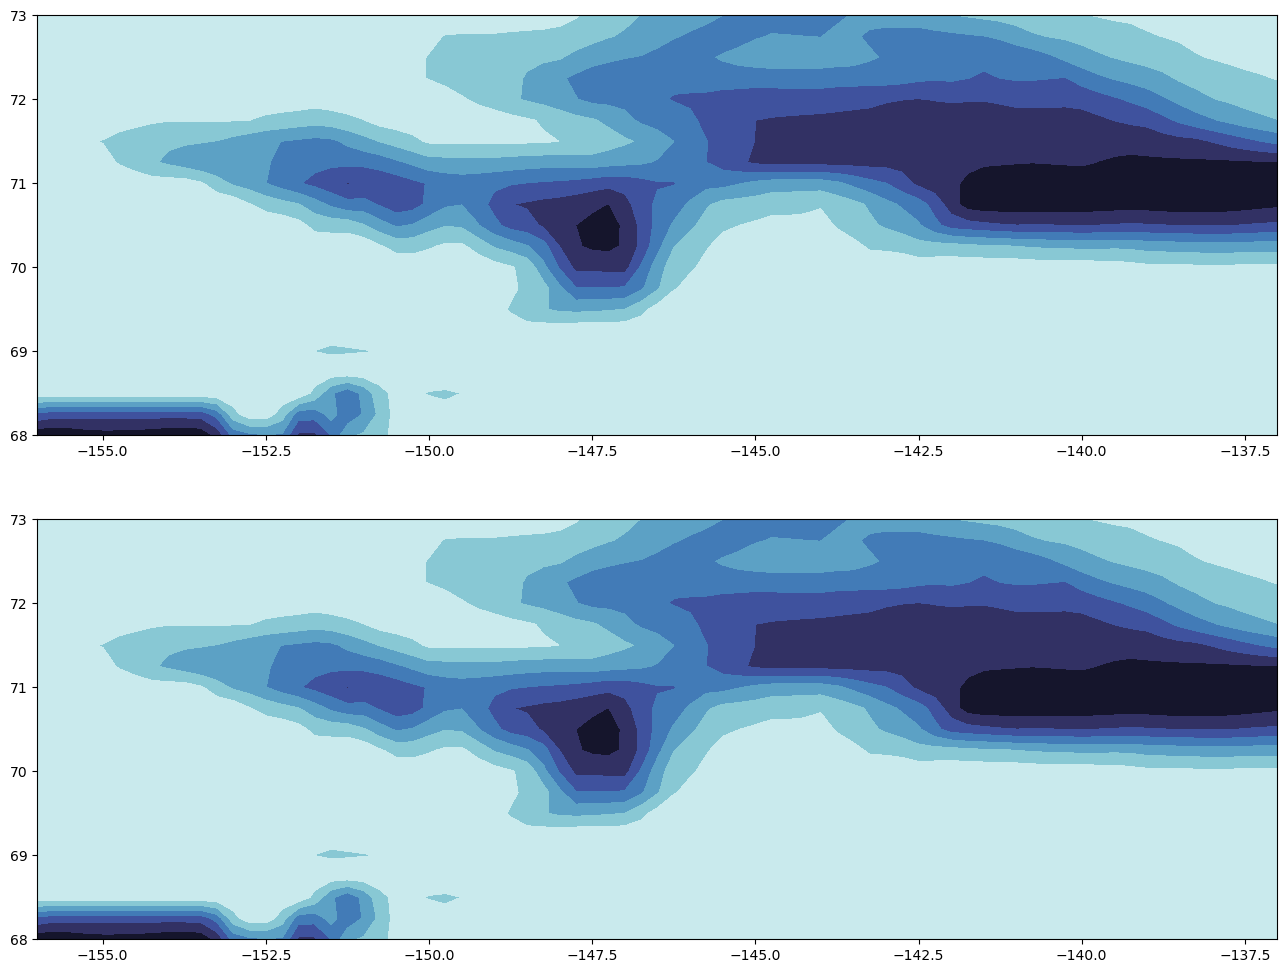

In [20]:
# Make some plots to compare 
# Plot surface longwave radition flux in forcing file and original data 

# Set the time to look at
t1 = 50000

# Make the figure 
fig, ax = plt.subplots(2, figsize=(16,12))

# Plot the forcing data
cs1 = ax[0].contourf(cloud_frc_file.lon.values, cloud_frc_file.lat.values, cloud_frc_file.cloud[t1,:,:],
            cmap=cmocean.cm.ice)

# Plot the original data
cs2 = ax[1].contourf(era5_cloud.longitude.values, era5_cloud.latitude.values, era5_cloud.tcc[t1,:,:].values,
                  cmap=cmocean.cm.ice)



Looks okay to me...